# Stage 13 — Connectivity across resolution

The connectivity score is the only ingredient that depends on DEM resolution, so it carries the **scale** question of this project: does D8 flow routing give the same answer at 2 m, 25 m and 100 m, and does the answer change the risk map? Mole Creek is the only place a 2 m run is practical, so it is compared with the 25 m run there; the 100 m run covers the whole state.

1. **Routing across resolution (13.1).** How closely the 2 m, 25 m and 100 m runs agree on the 66 Mole Creek polygons they share.
2. **Risk under 2 m and 25 m routing at Mole Creek (13.2).** Whether the finer routing changes the risk map.
3. **Do springs sit in high-D8 karst? (13.3).** The same independent check as Stage 10, applied to the D8 ratio itself.
4. **Does the routing agree with the Atlas catchments? (13.4).** The Karst Atlas flags were our first connectivity score and are now archived (`notebooks/archive/`). They survive as a check: D8 counts water arriving *into* a polygon, whereas the flags mark polygons whose own catchment drains *onto* karst, so the two are compared like for like.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
from scipy.stats import spearmanr

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_d8, D8_DECADE_EDGES, rasterize_max,
                   in_mole_creek_focus, mole_creek_focus_mask, aggregate_pressure_by_system, classify_fixed)
from hydro import slope_degrees, slope_risk_multiplier
from d8_routing import upstream_flag_counts

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

def corr_nonzero(a, b, valid_mask):
    m = valid_mask & ~np.isnan(a) & ~np.isnan(b) & ((a > 0) | (b > 0))
    return np.corrcoef(a[m], b[m])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

## 13.1 Does the resolution matter? The D8 routing at 2 m, 25 m and 100 m

The D8 routing follows the same method at three scales: `03alt2` (2 m DEM) and `03alt3` (25 m DEM) for the 66 core Mole Creek karst polygons, and the statewide 100 m run (`03-100m-hydrological-connectivity`) for all 1,677 mapped karst polygons. Comparing them over the 66 polygons they share shows whether the coarser grids lose what the finer grid sees. Each run counts, for a polygon, how many cells drain to it. The comparison uses the main score's four classes (powers of ten, see Stage 3), the upstream area, and the ratio of upstream cells to the polygon's own cells.

In [2]:
d8_2m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_2m_EPSG7855_jenks5.csv")
d8_25m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_jenks5.csv")
both = d8_2m.merge(d8_25m, on="target_objectid", suffixes=("_2m", "_25m"))
print(f"Core targets matched between the 2 m and 25 m runs: {len(both)}")

# Same fixed edges at every scale, as in the main score
s2 = np.digitize(both["upstream_cells_per_target_cell_2m"], D8_DECADE_EDGES, right=True) + 1
s25 = np.digitize(both["upstream_cells_per_target_cell_25m"], D8_DECADE_EDGES, right=True) + 1
print(f"\nLog class, 2 m:  {pd.Series(s2).value_counts().sort_index().astype(int).to_dict()}")
print(f"Log class, 25 m: {pd.Series(s25).value_counts().sort_index().astype(int).to_dict()}")
print(f"Same class at both resolutions: {(s2 == s25).mean() * 100:.0f}%; within one class: {(np.abs(s2 - s25) <= 1).mean() * 100:.0f}%")

a2, a25 = both["upstream_area_m2_2m"], both["upstream_area_m2_25m"]
print(f"\nUpstream area: rank correlation {spearmanr(a2, a25)[0]:.2f}, median 25 m / 2 m ratio {(a25 / a2).median():.2f}")
r2, r25 = both["upstream_cells_per_target_cell_2m"], both["upstream_cells_per_target_cell_25m"]
print(f"Upstream cells per target cell: rank correlation {spearmanr(r2, r25)[0]:.2f} (range {r2.max():.0f} at 2 m, {r25.max():.0f} at 25 m)")

d8_100m = pd.read_csv(outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv")
three = both.merge(d8_100m[["target_objectid", "upstream_area_m2", "target_raster_cells"]].rename(
    columns={"upstream_area_m2": "upstream_area_m2_100m", "target_raster_cells": "target_raster_cells_100m"}),
    on="target_objectid", how="left")
print(f"\nCore polygons also in the statewide 100 m run: {three['upstream_area_m2_100m'].notna().sum()} of {len(three)}")
print(f"Cells per core polygon at 100 m: median {three['target_raster_cells_100m'].median():.0f}; {(three['target_raster_cells_100m'] < 5).mean() * 100:.0f}% have fewer than 5")
print("\nUpstream area, rank correlation and median ratio between scales:")
for a, b, label in [("2m", "25m", "2 m vs 25 m"), ("25m", "100m", "25 m vs 100 m"), ("2m", "100m", "2 m vs 100 m")]:
    x, y = three[f"upstream_area_m2_{a}"], three[f"upstream_area_m2_{b}"]
    ok = x.notna() & y.notna()
    print(f"  {label:14s} rank correlation {spearmanr(x[ok], y[ok])[0]:.2f}, median ratio {(y[ok] / x[ok].replace(0, np.nan)).median():.2f} (n = {ok.sum()})")


Core targets matched between the 2 m and 25 m runs: 66

Log class, 2 m:  {1: 8, 2: 44, 3: 12, 4: 2}
Log class, 25 m: {1: 9, 2: 41, 3: 12, 4: 4}
Same class at both resolutions: 88%; within one class: 94%

Upstream area: rank correlation 0.81, median 25 m / 2 m ratio 1.00
Upstream cells per target cell: rank correlation 0.67 (range 197 at 2 m, 2303 at 25 m)

Core polygons also in the statewide 100 m run: 66 of 66
Cells per core polygon at 100 m: median 30; 12% have fewer than 5

Upstream area, rank correlation and median ratio between scales:
  2 m vs 25 m    rank correlation 0.81, median ratio 1.00 (n = 66)
  25 m vs 100 m  rank correlation 0.86, median ratio 0.96 (n = 66)
  2 m vs 100 m   rank correlation 0.86, median ratio 0.98 (n = 66)


**Result:** the D8 routing gives nearly the same answer at all three resolutions. Upstream area agrees across scales (rank correlation 0.81 between 2 m and 25 m, 0.86 between 25 m and 100 m, 0.86 between 2 m and 100 m, with median ratios of 0.96 to 1.00). At 25 m, 88% of the 66 polygons fall in the same class as at 2 m and 94% within one class (the 2 m run puts 8 / 44 / 12 / 2 polygons in classes 1 to 4, the 25 m run 9 / 41 / 12 / 4). The raw per-cell ratio agrees less (rank correlation 0.67 between 2 m and 25 m), partly because small polygons cover only a few 25 m cells, which inflates their ratio (up to about 2,300 at 25 m against 197 at 2 m).

So the coarser grids rank the targets almost as the 2 m grid does, which supports running this kind of signal at 25 m locally and 100 m statewide. They do not reproduce the fine detail inside a single target, and the 100 m grid is thin for small polygons: 12% of the core polygons have fewer than 5 cells, and 132 of the 1,677 statewide polygons (0.02% of karst area) have none.

## 13.2 Risk at Mole Creek under 2 m and 25 m routing

The 2 m run routes the same 66 karst polygons. Here its ratios are classed at the same fixed edges as the main score and put through the same equation (susceptibility x connectivity x aggregated pressure x slope, 2020 land cover, 25 m grid for the other layers), so the only thing that differs between the two risk maps is the DEM the water is routed on.

In [3]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure = src.read(1).astype(float); pressure_nodata = src.nodata
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape; cell = abs(src.transform.a)

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]

effective_pressure = aggregate_pressure_by_system(karst_mc, pressure, transform, pressure_nodata)
slope_factor = slope_risk_multiplier(slope_degrees(dem, dem_nodata, cell))

def risk_for(counts_csv):
    k = karst_mc.copy()
    add_connectivity_d8(k, counts_csv, scheme="decades")   # Atlas fallback only outside the routed polygons
    conn = rasterize_max(k, "connectivity", shape, transform, dtype="float32").astype(float)
    return np.where(valid, (intensity / 4.0) * (conn / 3.0) * (effective_pressure / 3.0) * slope_factor, np.nan), k

d8_2m_csv = outpath / "karst_upstream_connectivity_counts_core_mc_2m_EPSG7855_jenks5.csv"   # ratios; classes are recomputed here
d8_25m_csv = outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv"
risk_25m, k25 = risk_for(d8_25m_csv)
risk_2m, k2 = risk_for(d8_2m_csv)

m = valid
_, _, labels = classify_fixed(risk_25m, valid)
rows = []
for name, r, k in [("25 m routing (main)", risk_25m, k25), ("2 m routing", risk_2m, k2)]:
    rc, _, _ = classify_fixed(r, valid)
    row = {"routing": name, "mean risk": round(np.nanmean(r[m]), 4),
           "r vs 25 m": round(corr_nonzero(risk_25m, r, valid), 3),
           "rank corr vs 25 m": round(spearmanr(risk_25m[m], r[m])[0], 3)}
    row.update({f"% {labels[i]}": round((rc[m] == i).mean() * 100, 1) for i in range(len(labels)) if (rc[m] == i).any()})
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

table = named_ranking(risk_25m, karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk", "n_px"]].rename(columns={"mean_risk": "25 m routing"})
table["2 m routing"] = named_ranking(risk_2m, karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area:")
print(table.round(3).to_string())

c25 = k25.loc[k25["connectivity_source"] == "d8", "d8_class"]; c2 = k2.loc[k2["connectivity_source"] == "d8", "d8_class"]
print(f"\nPolygons routed: {len(c25)} at 25 m, {len(c2)} at 2 m; same class at both: {(c25.to_numpy() == c2.to_numpy()).mean() * 100:.0f}%")

            routing  mean risk  r vs 25 m  rank corr vs 25 m  % Very Low  % Low  % Moderate  % High  % Very High
25 m routing (main)     0.1237      1.000              1.000         1.9   36.2        38.5    16.9          6.6
        2 m routing     0.1247      0.974              0.986         1.9   35.9        38.0    17.1          7.0

Mean risk by Mole Creek area:
                              25 m routing    n_px  2 m routing
KNAME                                                          
Mole Creek  (Chudleigh Hill)         0.201     214        0.201
Mole Creek                           0.127  388198        0.128
Meander - Western Creek              0.067   24111        0.067

Polygons routed: 66 at 25 m, 66 at 2 m; same class at both: 88%


**Result:** routing on the 2 m DEM instead of the 25 m one barely changes the Mole Creek risk map. Mean risk is 0.125 against 0.124, the two maps correlate at r = 0.974 (rank correlation 0.986), the order of the three areas is the same (0.201, 0.128 and 0.067 against 0.201, 0.127 and 0.067), and the class shares move by under 1 point (Moderate 38.0% against 38.5%, Very High 7.0% against 6.6%).

So at Mole Creek the cheaper 25 m routing gives the same answer as the 2 m run, which is why the 25 m run is used there and the 2 m run is kept only as a check. The 100 m run agrees with the same polygons on upstream area (rank correlation 0.86 with both), but it is thin for small polygons (12% of the core polygons have fewer than 5 cells), which is the main cost of running statewide. Putting the 100 m risk surface on the Mole Creek grid, it correlates with the 25 m map at r = 0.80 (Stage 8).

### The same ground at three resolutions

Top row: the D8 connectivity class (1 to 4) of each karst polygon when the water is routed on the 2 m, 25 m and 100 m DEM. Bottom row: relative risk when connectivity comes from each routing. The window is a 5.5 x 4 km part of the Mole Creek karst; outlines are the karst polygons. Polygons too small for a 100 m cell are grey.

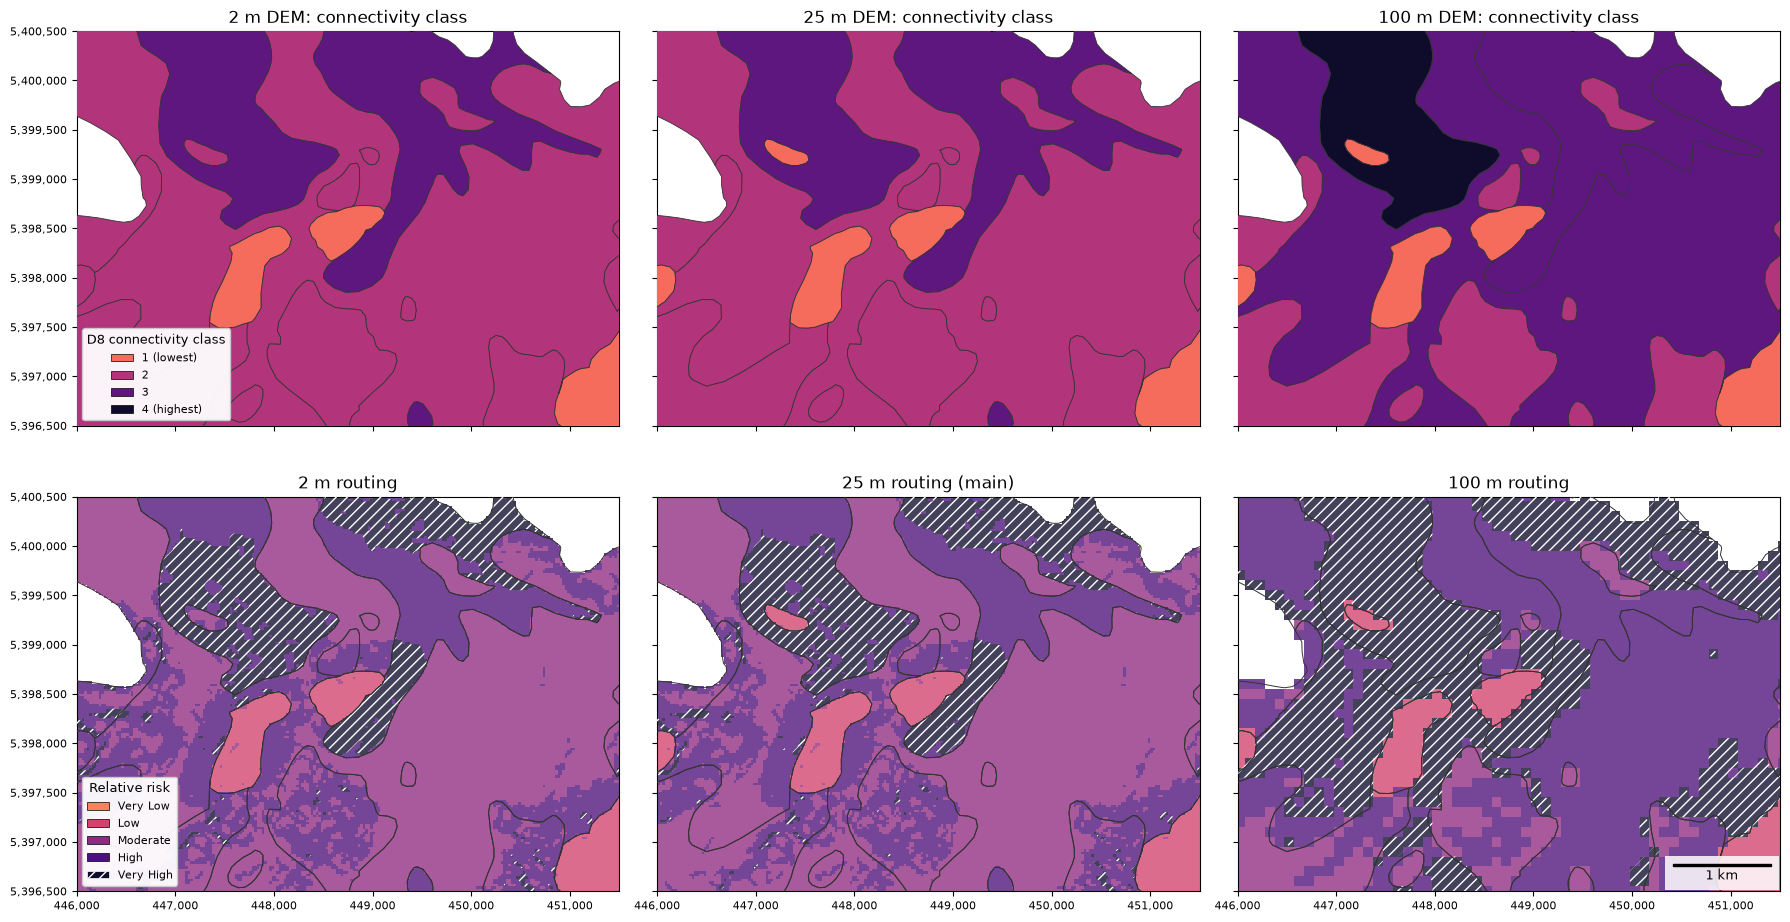

In [4]:
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from mapping import plot_risk, risk_legend, raster_extent, style_map_axes, add_scalebar

WINDOW = (446000, 5396500, 451500, 5400500)   # xmin, ymin, xmax, ymax (EPSG:7855)

# 100 m risk, restricted to the Mole Creek karst
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    risk_100 = src.read(1).astype("float64"); t100 = src.transform; n100 = src.nodata
inside_100 = geometry_mask(list(karst_only.geometry), out_shape=risk_100.shape, transform=t100, invert=True)
valid_100 = inside_100 & (risk_100 != n100)
risk_100 = np.where(valid_100, risk_100, np.nan)

risk_panels = [("2 m routing", risk_2m, valid, transform), ("25 m routing (main)", risk_25m, valid, transform), ("100 m routing", risk_100, valid_100, t100)]
class_panels = [classify_fixed(r, v) for _, r, v, _ in risk_panels]
risk_labels = class_panels[1][2]

fig, axes = plt.subplots(2, 3, figsize=(18, 9.6), sharex=True, sharey=True)
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from mapping import score_colours

k100 = karst_mc.copy()
add_connectivity_d8(k100, outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv", scheme="decades")
class_cols = score_colours(5, zero_transparent=False)[1:]
cmap5 = ListedColormap(class_cols)
for ax, (title, kdf) in zip(axes[0], [("2 m", k2), ("25 m", k25), ("100 m", k100)]):
    sub = kdf[(kdf["karst_intensity"] > 0) & in_mole_creek_focus(kdf)]
    unrouted = sub[sub["connectivity_source"] != "d8"]
    routed = sub[sub["connectivity_source"] == "d8"]
    if len(unrouted):
        unrouted.plot(ax=ax, color="#c9c9c9", edgecolor="#333333", linewidth=0.6, zorder=2)
    routed.plot(ax=ax, column="d8_class", cmap=cmap5, vmin=1, vmax=4, edgecolor="#333333", linewidth=0.6, zorder=3)
    ax.set_title(f"{title} DEM: connectivity class", fontsize=12)
axes[0][0].legend(handles=[Patch(facecolor=class_cols[i], edgecolor="black", linewidth=0.5, label=l) for i, l in enumerate(["1 (lowest)", "2", "3", "4 (highest)"])],
                  title="D8 connectivity class", loc="lower left", fontsize=8, title_fontsize=9, framealpha=0.95)
for ax, (title, _, _, tf), (rc, _, _) in zip(axes[1], risk_panels, class_panels):
    plot_risk(ax, rc, tf)
    karst_only.boundary.plot(ax=ax, color="#333333", lw=0.7, zorder=4)
    ax.set_title(title, fontsize=12)
for ax in axes.ravel():
    ax.set_xlim(WINDOW[0], WINDOW[2]); ax.set_ylim(WINDOW[1], WINDOW[3]); ax.set_aspect("equal")
    style_map_axes(ax)
    ax.set_xlabel(""); ax.set_ylabel("")
add_scalebar(axes[1][2], 1000, "1 km")
risk_legend(axes[1][0], risk_labels, loc="lower left")
plt.tight_layout()
fig.savefig(Path("..") / "figures" / "scale_resolution_mole_creek.png", dpi=170, bbox_inches="tight")
plt.show()

## 13.3 Do springs sit in high-D8 karst? The springs test

The statewide 100 m D8 run makes it possible to test the D8 signal against the same independent check used in Stage 10. The raw upstream area mostly measures polygon size, so the test uses the number of upstream cells per cell of the polygon itself. Each polygon is scored by its percentile rank on that ratio; springs within 500 m take the score of their nearest polygon; one value per named system is compared with 10,000 random same-size draws of polygons (weighted by area). The main intrinsic score (susceptibility x D8 class) and the Atlas intrinsic score are tested on exactly the same polygons for comparison.

In [5]:
karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
# connectivity becomes the D8 score (main); connectivity_atlas keeps the Atlas score (version 2)
add_connectivity_d8(karst_tas, outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv", scheme="decades")


,OBJECTID,KFEAT_ID,KLOCATION,KNAME,KREGION,KAREAMETRS,KAREAHA,KBOUNDARY,KCONFIRM,KCATEGORY,...,exposure_type,exposure_code,autogenic_score,proximal_score,distal_score,connectivity,connectivity_atlas,d8_ratio,d8_class,connectivity_source
0,1,0,NaN,NaN,NaN,843297.0,84.33,NaN,NaN,0,...,non-karst,0,0,0,0,0.0,0.0,NaN,NaN,atlas
1,2,0,NaN,NaN,BS,1695062.0,169.51,NaN,NaN,0,...,non-karst,0,0,0,0,0.0,0.0,NaN,NaN,atlas
2,3,0,NaN,NaN,BS,2471248.0,247.12,NaN,NaN,0,...,non-karst,0,0,0,0,0.0,0.0,NaN,NaN,atlas
3,4,0,NaN,NaN,BS,81982586.0,8198.26,NaN,NaN,0,...,non-karst,0,0,0,0,0.0,0.0,NaN,NaN,atlas
4,5,0,NaN,NaN,BS,1965360.0,196.54,NaN,NaN,0,...,non-karst,0,0,0,0,0.0,0.0,NaN,NaN,atlas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2596,2597,1866,NW 59,Roger River Hills,NW,95999.0,9.60,10,N,0,...,non-karst,0,0,3,0,3.0,3.0,NaN,NaN,atlas
2597,2598,335,NW 33,Lower Black River - South Forest,NW,6312.0,0.63,9,Y,B,...,exposed,3,3,0,0,3.0,3.0,NaN,NaN,atlas
2598,2599,2972,NW 33,Lower Black River - South Forest,NW,6312.0,0.63,9,Y,B,...,exposed,3,3,0,0,3.0,3.0,NaN,NaN,atlas
2599,2600,2973,NW 33,Lower Black River - South Forest,NW,4121.0,0.41,9,Y,B,...,exposed,3,3,0,0,1.5,3.0,3.0,2.0,d8


In [6]:
from scipy.stats import rankdata

d8_all = pd.read_csv(outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv")
kp = karst_tas[karst_tas["karst_intensity"] > 0].merge(
    d8_all[["target_objectid", "target_raster_cells", "upstream_cell_count"]], left_on="OBJECTID", right_on="target_objectid")
kp["area"] = kp.geometry.area
none_cells = kp["target_raster_cells"] == 0
print(f"Karst polygons with a 100 m D8 count: {len(kp)}; none has a cell on the 100 m grid: {none_cells.sum()} ({kp.loc[none_cells, 'area'].sum() / kp['area'].sum() * 100:.2f}% of karst area), excluded")
kp = kp[~none_cells].copy()
kp["d8_ratio"] = kp["upstream_cell_count"] / kp["target_raster_cells"]
kp["main_intrinsic"] = (kp["karst_intensity"] / 4.0) * (kp["connectivity"] / 3.0)
kp["atlas_intrinsic"] = (kp["karst_intensity"] / 4.0) * (kp["connectivity_atlas"] / 3.0)
print(f"D8 ratio against polygon size: rank correlation {spearmanr(kp['d8_ratio'], kp['area'])[0]:.2f}; against the Atlas intrinsic score: {spearmanr(kp['d8_ratio'], kp['atlas_intrinsic'])[0]:.2f}")

gde = gpd.read_file(inpath / "LIST_CFEV_GROUNDWATER_STATEWIDE/list_cfev_groundwater_statewide.shp").to_crs("EPSG:7855")
gde = gpd.clip(gde, gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg"))
core_types = ["Tufa-depositing spring", "Cold spring", "Subsurface stream"]
rng = np.random.default_rng(42)

def springs_percentile(col, types=None, max_dist=500):
    pct_rank = rankdata(kp[col]) / len(kp)
    polys = kp[["KNAME", "geometry"]].assign(v=pct_rank)
    pts = gde if types is None else gde[gde["GDE_TYPE"].isin(types)]
    near = gpd.sjoin_nearest(pts, polys, how="left", distance_col="dist_m")
    near = near[~near.index.duplicated(keep="first")]
    near = near[near["dist_m"] <= max_dist]
    by_system = near.groupby("KNAME")["v"].mean()
    weights = (kp["area"] / kp["area"].sum()).to_numpy()
    null = pct_rank[rng.choice(len(kp), size=(10000, len(by_system)), p=weights)].mean(axis=1)
    return len(by_system), (null < by_system.mean()).mean() * 100

rows = []
for col, label in [("d8_ratio", "D8 upstream cells per target cell"), ("main_intrinsic", "Main intrinsic score (D8 log classes x susceptibility)"), ("atlas_intrinsic", "Atlas intrinsic score (archived version, same polygons)")]:
    for type_label, types in [("all types", None), ("core types", core_types)]:
        n_sys, pct = springs_percentile(col, types)
        rows.append({"signal": label, "springs": type_label, "systems": n_sys, "percentile": round(pct, 1)})
print("\n" + pd.DataFrame(rows).to_string(index=False))

Karst polygons with a 100 m D8 count: 1677; none has a cell on the 100 m grid: 132 (0.02% of karst area), excluded
D8 ratio against polygon size: rank correlation 0.02; against the Atlas intrinsic score: 0.05



                                                 signal    springs  systems  percentile
                      D8 upstream cells per target cell  all types       24        69.6
                      D8 upstream cells per target cell core types       17        46.4
 Main intrinsic score (D8 log classes x susceptibility)  all types       24        85.6
 Main intrinsic score (D8 log classes x susceptibility) core types       17        82.3
Atlas intrinsic score (archived version, same polygons)  all types       24        98.5
Atlas intrinsic score (archived version, same polygons) core types       17        99.1


**Result:** the D8 ratio measures something different from the Atlas score. It is unrelated to polygon size (rank correlation 0.02) and to the Atlas intrinsic score (0.05). The ratio alone does not predict where springs are: they sit near the middle of its distribution (about the 70th percentile for all spring types, the 46th for the core types). The main intrinsic score (susceptibility times the D8 class) does better, at the 86th (all types) and 82nd (core types) percentile, but both sit below the Atlas intrinsic score on the same polygons (98.5th and 99.1st). Stage 10 tests the main score against the same springs with an area-weighted null on the intrinsic values themselves and gets the 96.5th and 94.6th percentile.

Springs mark where water emerges, not where it enters, so this is a weak test for a recharge signal. It does mean the D8 score on its own has no independent validation of its own. The scale result in 13.1 and 13.2 shows the routing is stable across resolution, and 13.4 shows it is consistent with the Atlas catchments.

## 13.4 Does the routing agree with the Atlas catchments? A like-for-like check

The raw D8 ratio and the Atlas connectivity score point in different directions: the ratio measures water arriving **into** a polygon, whereas `KPROXCATCH` marks polygons that drain **onto** karst. They should not be expected to rank polygons the same way, and they do not (rank correlations below). The like-for-like question is different: of the cells that D8 routes into a polygon from outside it, how many lie inside Atlas proximal catchments? If the Atlas catchments are a fair map of where karst water comes from, that share should be well above the proximal catchments' share of the landscape.

The 25 m run already records this count (the saved 2 m file does not separate the polygons' own cells, so it is left out). For the 100 m run it is computed here from the saved D8 pointer and the proximal-catchment raster (`d8_routing.upstream_flag_counts`), and cached.

In [7]:
def external_share(df, upstream_flag_col):
    """Water arriving from outside each polygon: total cells, and the flagged part."""
    outside = df["upstream_cell_count"] - (df["target_raster_cells"] - df["target_cells_excluded_from_total"])
    return pd.DataFrame({"outside": outside, "flagged": df[upstream_flag_col]}).assign(target_objectid=df["target_objectid"])

# 100 m statewide: compute (or reuse) the flagged counts from the saved D8 pointer
cache_100m = outpath / "karst_upstream_proximal_counts_tas_100m_EPSG7855.csv"
targets_100m = karst_tas[karst_tas["karst_intensity"] > 0].reset_index(drop=True)
if cache_100m.is_file():
    flag_100m = pd.read_csv(cache_100m)
else:
    flag_100m = upstream_flag_counts(outpath / "d8_pointer_tas_100m_EPSG7855.tif", targets_100m,
                                     outpath / "kproxcatch_presence_tas_100m_EPSG7855.tif")
    flag_100m.to_csv(cache_100m, index=False)
f100 = flag_100m.rename(columns={"OBJECTID": "target_objectid", "upstream_cells": "outside", "upstream_flagged": "flagged"})
f100 = f100[f100["target_cells"] > 0][["target_objectid", "outside", "flagged"]]

d8_25m_raw = pd.read_csv(outpath / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv")
f25 = external_share(d8_25m_raw, "upstream_kproxcatch_cells_excluding_target")
d8_100m_all = pd.read_csv(outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv")

with rasterio.open(outpath / "kproxcatch_presence_tas_100m_EPSG7855.tif") as src:
    kp_grid = src.read(1)
with rasterio.open(outpath / "d8_pointer_tas_100m_EPSG7855.tif") as src:
    ptr_valid = src.read(1) != src.nodata
share_of_landscape = ((kp_grid == 1) & ptr_valid).sum() / ptr_valid.sum()

atlas_score = karst_tas.set_index("OBJECTID")["connectivity_atlas"]
rows = []
for label, f, ratio_df in [("Mole Creek 25 m", f25, d8_25m_raw), ("Tasmania 100 m", f100, d8_100m_all)]:
    e = f[f["outside"] > 0]
    r = ratio_df.set_index("target_objectid")["upstream_cells_per_target_cell"].dropna()
    a = atlas_score.reindex(r.index)
    rows.append({"run": label, "polygons with outside drainage": len(e),
                 "receive from proximal catchment %": round((e["flagged"] > 0).mean() * 100, 1),
                 "median share of outside drainage %": round((e["flagged"] / e["outside"]).median() * 100, 1),
                 "pooled share %": round(e["flagged"].sum() / e["outside"].sum() * 100, 1),
                 "rank corr, D8 ratio vs Atlas score": round(spearmanr(r.loc[a.notna()], a.dropna())[0], 2)})
print(f"Proximal catchments cover {share_of_landscape * 100:.1f}% of the statewide valid cells (the share expected by chance).\n")
print(pd.DataFrame(rows).to_string(index=False))

Proximal catchments cover 11.1% of the statewide valid cells (the share expected by chance).

            run  polygons with outside drainage  receive from proximal catchment %  median share of outside drainage %  pooled share %  rank corr, D8 ratio vs Atlas score
Mole Creek 25 m                              63                               92.1                                73.1            67.8                               -0.21
 Tasmania 100 m                            1410                               81.1                                74.5            27.5                               -0.10


**Result:** the Atlas proximal catchments are a fair map of where the routed water comes from. At Mole Creek (25 m), 92% of the 63 polygons with drainage arriving from outside receive some of it from an Atlas proximal catchment, and a median of 73% (67.8% pooled) of that outside drainage lies in them. Statewide (100 m), 81% of the 1,410 such polygons receive from a proximal catchment, with a median share of 74.5% and a pooled share of 27.5%. Proximal catchments cover only 11.1% of the statewide landscape, so the pooled share is about 2.5 times what chance would give.

The raw scores still do not agree: the rank correlation between the D8 ratio and the Atlas score is -0.21 at Mole Creek and -0.10 statewide. That is expected, because the ratio rewards karst low in a large catchment, whereas the Atlas flags mark the source side, so a polygon flagged proximal is typically a headwater with little drainage arriving. The two are complementary views of the same system, not competing estimates of one quantity. The routed score is the better main choice because it varies across the karst (the Atlas puts most Mole Creek polygons at the maximum, 3); the Atlas score is archived (`notebooks/archive/`).

**Limitations.** Own cells are removed from both counts, because 60% of polygons are themselves flagged and including them would inflate the overlap. The 100 m run drops the 132 polygons too small for a cell, and the saved 2 m file does not separate own cells, so this check is run at 25 m and 100 m only.